# Example: Tracing a Particle in a Dipole Field

Here we use the `BorisIntegrator` as well, this time to calculate the trajectory of a gyrating particle in a dipole field similar to Earth's.

The main new thing here is actually the use of discretized (gridded) electromagnetic field data.

Again, let's start by importing some libraries. `matplotlib` and `numpy` are pretty universal. `scipy.constants` is for physical constants. Finally `ggcmpy.tracing` is where the tracing functionality currently lives.

`pyvista` is a library for (interactive) 3D visualization. It can be helpful to make sense of 3D trajectories, though those visualizations also could use more work still.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import pyvista as pv
from scipy import constants

import ggcmpy.tracing


def gyro_frequency(B: float, q: float, m: float, gamma: float) -> float:
    return np.abs(q) * B / (gamma * m)  # type: ignore[no-any-return]


def to_mesh_lines(df):
    positions = df[["x", "y", "z"]].to_numpy()
    mesh = pv.PolyData(positions)
    lines = pv.lines_from_points(positions)
    return mesh, lines


# utility function to plot trajectory using pyvista
def plot_trajectory(plotter, df, **kwargs):
    _, lines = to_mesh_lines(df)
    plotter.add_mesh(lines, **kwargs)


def plot_trajectories(plotter, dfs, **kwargs):
    for df in dfs:
        plot_trajectory(plotter, df, **kwargs)

Running cmake --build & --install in /Users/kai/src/openggcm/ggcmpy/build/cp314-cp314-macosx_14_0_arm64


## Analytical and Discretized Dipole Field

Let's start by defining Earth's dipole field (with the dipole being oriented straight North/South).

`emfields.dipole` just implements the analytic formula for a magnetic dipole.

In [2]:
field = ggcmpy.tracing.emfields.dipole(m=np.array([0.0, 0.0, 8e22]))  # [A m^2]

### Define a Grid

Let's define the coordinates of a simple grid extending from $-10 R_E$ to $R_E$. `x`, `y`, `z` are the cell centered coordinates -- in OpenGGCM, that's where the fluid quantities (density, pressure, velocity) live.

`x_nc`, `y_nc`, `z_nc` are the node-centered coordinates, ie., the actual boundaries of the computational cells.

In [3]:
R_E = 6.371e6  # [m]
x = np.linspace(-10 * R_E, 10 * R_E, 20)
y = np.linspace(-10 * R_E, 10 * R_E, 20)
z = np.linspace(-10 * R_E, 10 * R_E, 20)
x_nc = 0.5 * (x[1:] + x[:-1])
y_nc = 0.5 * (y[1:] + y[:-1])
z_nc = 0.5 * (z[1:] + z[:-1])
coords = {"x": x, "y": y, "z": z, "x_nc": x_nc, "y_nc": y_nc, "z_nc": z_nc}

### Create field dataset in cell-centered format

This is actually not how things should be done, since the electric and magnetic field in OpenGGCM live on the Yee grid (see below). However, it's somewhat useful for testing the various interpolations, and it also might be useful if one doesn't have the extended OpenGGCM output available, in which case one has to make do with just the B-field that has been interpolated onto cell centers.

`ggcmpy.tracing.discretize_emfields_cc()` is mostly useful for testing -- it takes a field that is defined at any position (usually because it's an analytic expression) and discretizes it onto the grid specified.

In [4]:
field_cc = ggcmpy.tracing.discretize_emfields_cc(coords, field)
field_cc

<xarray.Dataset> Size: 385kB
Dimensions:  (x: 20, y: 20, z: 20, x_nc: 19, y_nc: 19, z_nc: 19)
Coordinates:
  * x        (x) float64 160B -6.371e+07 -5.7e+07 ... 5.7e+07 6.371e+07
  * y        (y) float64 160B -6.371e+07 -5.7e+07 ... 5.7e+07 6.371e+07
  * z        (z) float64 160B -6.371e+07 -5.7e+07 ... 5.7e+07 6.371e+07
  * x_nc     (x_nc) float64 152B -6.036e+07 -5.365e+07 ... 5.365e+07 6.036e+07
  * y_nc     (y_nc) float64 152B -6.036e+07 -5.365e+07 ... 5.365e+07 6.036e+07
  * z_nc     (z_nc) float64 152B -6.036e+07 -5.365e+07 ... 5.365e+07 6.036e+07
Data variables:
    bx       (x, y, z) float64 64kB 5.954e-09 6.327e-09 ... 6.327e-09 5.954e-09
    by       (x, y, z) float64 64kB 5.954e-09 6.327e-09 ... 6.327e-09 5.954e-09
    bz       (x, y, z) float64 64kB -1.249e-24 -9.402e-10 ... -1.249e-24
    ex       (x, y, z) float64 64kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    ey       (x, y, z) float64 64kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    ez       (x, y, z) float64 64kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

### Create field dataset discretized on Yee grid

This is rather similar to the above, but actually discretizes the electromagnetic field on the Yee grid, where these fields in OpenGGCM actually live.

In [5]:
field_yee = ggcmpy.tracing.discretize_emfields_yee(coords, field)
field_yee

<xarray.Dataset> Size: 357kB
Dimensions:  (x_nc: 19, y: 20, z: 20, x: 20, y_nc: 19, z_nc: 19)
Coordinates:
  * x_nc     (x_nc) float64 152B -6.036e+07 -5.365e+07 ... 5.365e+07 6.036e+07
  * y        (y) float64 160B -6.371e+07 -5.7e+07 ... 5.7e+07 6.371e+07
  * z        (z) float64 160B -6.371e+07 -5.7e+07 ... 5.7e+07 6.371e+07
  * x        (x) float64 160B -6.371e+07 -5.7e+07 ... 5.7e+07 6.371e+07
  * y_nc     (y_nc) float64 152B -6.036e+07 -5.365e+07 ... 5.365e+07 6.036e+07
  * z_nc     (z_nc) float64 152B -6.036e+07 -5.365e+07 ... 5.365e+07 6.036e+07
Data variables:
    bx1      (x_nc, y, z) float64 61kB 6.152e-09 6.579e-09 ... 6.152e-09
    by1      (x, y_nc, z) float64 61kB 6.152e-09 6.579e-09 ... 6.152e-09
    bz1      (x, y, z_nc) float64 61kB -4.437e-10 -1.49e-09 ... -4.437e-10
    eflx     (x, y_nc, z_nc) float64 58kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    efly     (x_nc, y, z_nc) float64 58kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    eflz     (x_nc, y_nc, z) float64 58kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

### Set up Boris pusher parameters

This is similar to how we set up the Boris pusher before in a uniform field. We again choose an electron, though it's fudged to be really hot so one can see it's gyration on the global scale. It is initialized at a distance of $5 R_E$ in the equatorial plane.

In [6]:
q, m = -constants.e, constants.m_e
x0 = np.array([5.0 * R_E, 0.0, 0.0])  # [m]
B_x0 = field.B(x0)

E_kin = 10.0 * 1e6 * constants.e  # 10 MeV in J
gamma = 1.0 + E_kin / (m * constants.c**2)
v_e = constants.c * np.sqrt(1.0 - 1.0 / gamma**2)

v0 = np.array([0.0, v_e / np.sqrt(2.0), v_e / np.sqrt(2.0)])  # [m/s]
u0 = gamma * v0 / constants.c
prts = pd.DataFrame(
    np.array([[0.0, *x0, *u0]]), columns=["time", "x", "y", "z", "ux", "uy", "uz"]
)

om_ce = gyro_frequency(np.linalg.norm(B_x0), q, m, gamma)
r_ce = m * np.linalg.norm(u0) * constants.c / (np.abs(q) * np.linalg.norm(B_x0))  # [m]

print(f"B={B_x0} [T] om_ce={om_ce:.2f} [1/s] r_ce={r_ce / R_E:.2f} [R_E]")  # noqa: T201

t_final = 100.0 * 2 * np.pi / om_ce  # [s]
dt = 1.0 / om_ce / 10.0

B=[ 0.00000000e+00  0.00000000e+00 -2.47489717e-07] [T] om_ce=2116.19 [1/s] r_ce=0.02 [R_E]


### Trace particle based on analytic dipole field

In [7]:
boris = ggcmpy.tracing.integrator.boris_python(field, q=q, m=m)
df = boris.integrate(prts, t_final=t_final, snapshot_interval_steps=1)

### Trace particle based cell centered discretized field

In [8]:
boris_cc = ggcmpy.tracing.legacy.BorisIntegrator_python(field_cc, q=q, m=m)
df_cc = boris_cc.integrate(x0, u0, t_final)

### Trace particle based Yee grid discretized field

In [9]:
boris_yee = ggcmpy.tracing.integrator.boris_python(field_yee, q=q, m=m)
df_yee = boris_yee.integrate(prts, t_final=t_final, snapshot_interval_steps=1)

### Trace particle based Yee grid discretized field in C++

In [10]:
boris_yee_cxx = ggcmpy.tracing.integrator.boris_cxx(field_yee, q=q, m=m)
df_yee_cxx = boris_yee_cxx.integrate(prts, t_final=t_final, snapshot_interval_steps=1)

### Trace particle based on Yee grid discretized field using Fortran

This is the only variant that's currently implemented in Fortran, as it's hopefully the only one that's really needed.

As one would hope, it is much faster.

In [11]:
boris_f2py = ggcmpy.tracing.legacy.BorisIntegrator_f2py(field_yee, q=q, m=m)
df_f2py = boris_f2py.integrate(x0, u0, 100 * t_final, dt_max=dt)

### Trace field lines

In [12]:
import pandas as pd
import scipy.integrate


def trace_field_line(r0, get_B, r_min=0.5, r_max=10.0):
    """Trace a magnetic field line starting at position r0 in the field
    provided by the get_B function.

    This function integrates the field line in the positive direction
    until it get either closer than `r_min` to the origin, or outside of `r_max`.

    Returns a pandas DataFrame with columns 'time', 'x', 'y', 'z'.
    """

    def rhs(t, x):  # noqa: ARG001
        B = get_B(x)
        B /= np.linalg.norm(B)
        return B

    def outside(t, x):  # noqa: ARG001
        return np.linalg.norm(x) - r_max  # stop if r > r_max

    outside.terminal = True
    outside.direction = 1  # only trigger when approaching from inside

    def inside(t, x):  # noqa: ARG001
        return np.linalg.norm(x) - r_min  # stop if r < r_min

    inside.terminal = True
    inside.direction = -1  # only trigger when approaching from outside

    tf = 1e9
    sol = scipy.integrate.solve_ivp(
        rhs, (0.0, tf), r0, events=[outside, inside], max_step=0.1 * R_E
    )
    sol2 = scipy.integrate.solve_ivp(
        rhs, (tf, 0.0), r0, events=[outside, inside], max_step=0.1 * R_E
    )
    dfs = [
        pd.DataFrame(np.column_stack((s.t, s.y.T)), columns=["time", "x", "y", "z"])
        for s in [sol, sol2]
    ]
    return pd.concat((dfs[1].iloc[::-1], dfs[0]), ignore_index=True)


def trace_field_lines(seeds, B_func, integrate_kwargs):
    """Trace multiple field lines.

    This is a convenience wrapper around trace_field_line.
    `seeds` is a list of starting positions.
    `B_func` is the magnetic field function.
    `integrate_kwargs` is a dictionary of additional keyword arguments to pass to
    `trace_field_line`.

    Returns a list of pandas DataFrames, one per seed point."""
    return [trace_field_line(r0, B_func, **integrate_kwargs) for r0 in seeds]


seeds = [
    r * np.array([np.cos(phi), np.sin(phi), 0.0])
    for phi in np.linspace(0.0, 2.0 * np.pi, 16, endpoint=False)
    for r in [3.0 * R_E, 5.0 * R_E]
]

dfs = trace_field_lines(
    seeds, field.B, integrate_kwargs={"r_min": 2 * R_E, "r_max": 20.0 * R_E}
)

### Plot the resulting trajectories

All four trajectories describe the same physics, but numerically they are different because of the different ways the fields are
provided / interpolated.

There are two implementations for the Yee grid discretized variant (Python and Fortran). These are green and orange, and one would hope for those two to agree -- and they do.

In [13]:
plotter = pv.Plotter()
plot_trajectory(plotter, df, line_width=1, color="blue")
plot_trajectory(plotter, df_cc, line_width=1, color="red")
plot_trajectory(plotter, df_yee, line_width=1, color="green")
plot_trajectory(plotter, df_yee_cxx, line_width=1, color="magenta")
plot_trajectory(plotter, df_f2py, line_width=1, color="orange")
plot_trajectories(plotter, dfs, line_width=1, color="gray")
plotter.show()

Widget(value='<iframe src="http://localhost:61369/index.html?ui=P_0x3212674d0_0&reconnect=auto" class="pyvista…

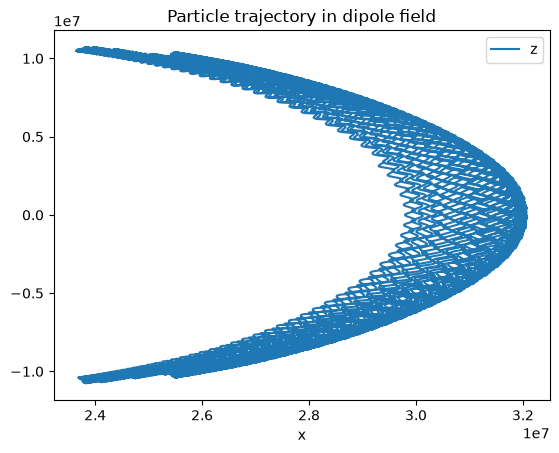

In [14]:
# df_f2py.plot.scatter(x="x", y="z", c="time", marker=".", colorbar=True)
df_f2py.plot(x="x", y="z", title="Particle trajectory in dipole field");